In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
# For one step reaction
y0_onestep = {
    'S_1' : (20, 60),
    'S_2' : (100, 100),
    'S_out' : (0, 0),
}

y0_latent = {
    'S_1' : (20, 60),
    'S_2' : (100, 100),
    'S_3' : (0, 0),
    'S_4' : (0, 0),
    'S_out' : (0, 0),
}
ks_onestep = [2e4*1e-9]
ks_latent = [2e5*1e-9, 2e7*1e-9]

time_hours = 1 #hours
t_end = time_hours * 3600  # seconds



data_gen_one_step = SyntheticDataGenerator(
    mechanism='one_step',
    reaction_rates=ks_onestep,
    initial_concentration_ranges=y0_onestep,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
    E_bounds=(-np.inf, np.inf)
)

data_gen_latent = SyntheticDataGenerator(
    mechanism='one_step_1latent',
    reaction_rates=ks_latent,
    initial_concentration_ranges=y0_latent,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
    E_bounds=(-np.inf, np.inf)
)

In [14]:
sampling_dim = 4
c_ranges = [
    (1, 100),  # S_1
    (1, 100),  # S_2
    (0,0)
]
k_ranges = [
    (1*1e-9, 1e5*1e-9)  # k1,
]
grid_results = data_gen_one_step.grid_search(sampling_dim = sampling_dim,
                              c_ranges=c_ranges,
                              k_ranges=k_ranges)

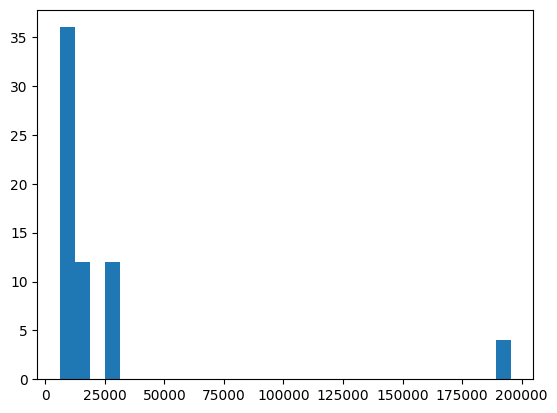


      Mean E: 24182.473961358995
      Std E: 44803.81807368401
      Max E: 195460.83443549954
      Min E: 6092.018353580556

      Best info: c0=(np.float64(1.0), np.float64(100.0), 0) k=[1.]
      Worst info: c0=(np.float64(1.0), np.float64(1.0), 0) k=[1.]
      


In [ ]:
E_dist = [res['E'] for res in grid_results]
plt.hist(E_dist, bins=30)
plt.show()

print(f'''
      Mean E: {np.mean(E_dist)}
      Std E: {np.std(E_dist)}
      Max E: {np.max(E_dist)}
      Min E: {np.min(E_dist)}
      
      Best info: c0={grid_results[np.argmin(E_dist)]['c0']} k={np.array(grid_results[np.argmin(E_dist)]['k'])}
      Worst info: c0={grid_results[np.argmax(E_dist)]['c0']} k={np.array(grid_results[np.argmax(E_dist)]['k'])}
      ''')

In [18]:
sampling_dim = 4
c_ranges = [
    (1, 100),  # S_1
    (1, 100),  # S_2
    (0,0), # S_3
    (0,0), # S_4
    (0,0) # S_out
]
k_ranges = [
    (1*1e-9, 1e5*1e-9)  # k1,
    ,(1e-3, 1e2)  # k2,
]
grid_results = data_gen_latent.grid_search(sampling_dim = sampling_dim,
                              c_ranges=c_ranges,
                              k_ranges=k_ranges)

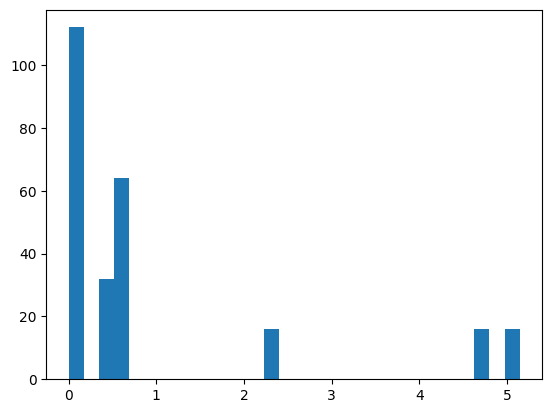


      Mean E: 0.9854191200109406
      Std E: 1.5938965489888628
      Max E: 5.142589201861892
      Min E: 9.622606193176579e-09

      Best info: c0=(np.float64(100.0), np.float64(1.0), 0, 0, 0) k=[1.e-09 1.e-03]
      Worst info: c0=(np.float64(100.0), np.float64(100.0), 0, 0, 0) k=[1.e-09 1.e-03]
      


In [19]:
E_dist = [res['E'] for res in grid_results]
plt.hist(E_dist, bins=30)
plt.show()

print(f'''
      Mean E: {np.mean(E_dist)}
      Std E: {np.std(E_dist)}
      Max E: {np.max(E_dist)}
      Min E: {np.min(E_dist)}
      
      Best info: c0={grid_results[np.argmin(E_dist)]['c0']} k={np.array(grid_results[np.argmin(E_dist)]['k'])}
      Worst info: c0={grid_results[np.argmax(E_dist)]['c0']} k={np.array(grid_results[np.argmax(E_dist)]['k'])}
      ''')